In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer
import onnx
import onnxruntime as ort
from dotenv import load_dotenv
import os
import requests
import umap
import time
from sklearn.cluster import MiniBatchKMeans

load_dotenv()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.version.cuda)
print(f"running on {device}")

D = 256

%matplotlib widget

13.0
running on cpu


# Schema

## vector index -> metadata -> texts collection

### Vector index
Many to one entries of encoded text. This is where the news articles are encoded and placed into latent space. Each of these has the index of the start and end of a metadata entry in a .bin file

### Metadata
Stored in a .bin file with standard entries including title, date, publisher, original link, topics, etc. Main thing it has is two numbers for start and end index of full text. Helps add abstraction layer for just wanting metadata

### Text storage
.bin file containing every piece of text back to back to back.

In [2]:
model = onnx.load("whereswaldo.onnx")
onnx.checker.check_model(model)
print("model is valid")

try:
    tokenizer = AutoTokenizer.from_pretrained("./mpnet_tokenizer")
except:
    tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")
    tokenizer.save_pretrained("./mpnet_tokenizer")

session = ort.InferenceSession(
    "whereswaldo.onnx",
    providers = ["CPUExecutionProvider"]
)
print(session.get_providers())

def encode_onnx(x, tokenizer = tokenizer, session = session):
    batch = tokenizer(
        x,
        padding = True,
        truncation = True,
        max_length = 256,
        return_overflowing_tokens=True,
        stride = 24,
        return_tensors = "np",
    )

    outputs = session.run(
        ["embeddings"],
        { 
            "input_ids" : batch["input_ids"].astype(np.int64), 
            "attention_mask" : batch["attention_mask"].astype(np.int64)
        }
    )

    return F.normalize(torch.tensor(outputs[0]), p = 2, dim = -1), batch["overflow_to_sample_mapping"]

model is valid
['CPUExecutionProvider']


In [27]:
NEWS_API = os.getenv("NEWS_API_KEY")
url = "https://api.freenewsapi.io/v1/news"
query = "us politics"

params = {
    "q": query,
    "language": "en",
    "page_size" : 10
}

headers = {
    "x-api-key": NEWS_API
}

CURSOR_FILE = "last_fetch.json"
reads = {}
try:
    with open(CURSOR_FILE) as f:
        reads = json.load(f)
        published_after = reads[query]["last_published_at"]
    print(f"Fetching articles after {published_after}")
except:
    published_after = None
    print("First run, fetching all articles")

if published_after:
    params["published_after"] = published_after

all_articles = []

for i in tqdm(range(100)):
    r = requests.get(url, params=params, headers=headers)
    data = r.json()
    all_articles.extend(data["data"])

    if data["meta"]["has_more"]:
        params["cursor"] = data["meta"]["next_cursor"]
        time.sleep(0.6)
    else:
        break

if all_articles:
    latest = max(all_articles, key=lambda a: a["published_at"])
    with open(CURSOR_FILE, "w") as f:
        reads[query] = {}
        reads[query]["last_published_at"] = latest["published_at"]
        json.dump(reads, f)
    print(f"Checkpoint saved: {latest['published_at']}")

print(f"Got {len(all_articles)} new articles")

uuids = [art["uuid"] for art in all_articles]

print(uuids)

Fetching articles after 2026-05-06T21:30:15.000Z


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [06:46<00:00,  4.06s/it]

Checkpoint saved: 2026-05-11T22:22:12.000Z
Got 1000 new articles
['e586e4eb-a869-45b5-bff2-9abec8b701ce', 'e84ae8d0-2d66-41d4-b562-220e5b847201', '94aafd1e-cd33-4079-af7f-803f33421960', '134d3c32-ca93-46bd-8b92-446b5689c8f7', '2b4ca2ce-1397-4bde-8285-367e131383e1', 'b7a5e635-653f-43bf-91bf-599047f810ec', '1fbf6de2-5526-4e31-9a3b-1ad7e74315f0', '40f596ab-3b3a-44e5-8be7-b1eb8f0169bb', '3ac5842e-c46d-4b7c-b025-7d3c76f41d6e', 'b97725f0-8adf-4bfb-9c99-b72c60e773dd', 'a44a91be-3f0b-4019-a1a8-64bd1385cb01', 'a90b7027-f5b9-4e88-acd8-91b50e06c0ad', '58354f64-5dab-48d8-95a4-aa39de1abbdb', '68882b1e-2321-41be-a0d6-a0eea03c6360', '00ddfce4-11f4-46ed-8524-64bfc48e699d', '2a0aacba-272a-4204-82e4-04e6de810686', 'd2e4b003-b505-4ce2-a74a-ed29c59810d0', 'f683d067-012c-4a23-bd07-05e932303252', '6e2c0ec1-070e-4124-944a-44364b45b345', '8a76eea4-9e14-4b1c-a2f0-2ac891c4e439', '32be0a06-35f8-4e53-b00a-5f0a25c05368', '77e6f86c-beaf-40a5-b1e5-a8e93a300aca', '43ae4677-9b4c-442c-b897-a152f59124fa', '05818946-4d27

In [ ]:
# for constructing

records = []

for uuid in tqdm(uuids):
    r = requests.get(
        "https://api.freenewsapi.io/v1/details",
        params={"uuid": uuid},
        headers=headers
    )
    try:
        records.append(r.json()["data"])
        time.sleep(0.4)
    except Exception as e:
        print(f"Error in uuid {uuid}: {e}")
        print(r.json())

with open("articles.json", "w") as file:
    json.dump(records, file)

records = json.loads(open("articles.json", "r").read())

print(records[0])

{'uuid': 'e586e4eb-a869-45b5-bff2-9abec8b701ce', 'title': 'A Sealed Well and Bronze Sword Reveal the Iron Age Transformation of a 3,200-Year-Old Sardinian Tower', 'thumbnail': 'https://arkeonews.net/wp-content/uploads/2026/05/Nuraghe-Barru-.jpg', 'publisher': 'Arkeonews', 'authors': ['Leman Altuntas'], 'topics': ['social sciences'], 'countries': ['BW', 'ID', 'LV', 'NA'], 'languages': ['en'], 'published_at': '2026-05-11T22:22:12.000Z', 'original_url': 'https://arkeonews.net/a-sealed-well-and-bronze-sword-reveal-the-iron-age-transformation-of-a-3200-year-old-sardinian-tower/', 'incipit': 'A 3,200-year-old nuraghe in Sardinia reveals how Bronze Age towers were reused as Iron Age cult sites through a sealed well, ritual pottery and a votive bronze sword.', 'body': 'A 3,200-year-old nuraghe in Sardinia reveals how Bronze Age towers were reused as Iron Age cult sites through a sealed well, ritual pottery and a votive bronze sword. For centuries, Sardinia’s stone towers stood over the island 

In [ ]:
class DBAccessApi:
    def __init__(self, vector_path, packed_offsets_path, meta_path, text_path, index_path, embedding_session=session, embedding_tokenizer=tokenizer):
        self.vector_path = vector_path
        self.packed_offsets_path = packed_offsets_path
        self.meta_path = meta_path
        self.text_path = text_path
        self.index_path = index_path
        self.index_offset_path = self.index_path + ".offsets"
        self.index_mapping_path = self.index_path + ".mapping"
        self.sorted_vector_path = self.vector_path + ".sorted"

        self.embedder = embedding_session
        self.tokenizer = embedding_tokenizer

        self.packed_offset_type = np.dtype([
            ("metadata_start", np.uint64),
            ("metadata_end", np.uint64),
            ("full_text_start", np.uint64),
            ("full_text_end", np.uint64),
        ])

        self.D = 256
        self.ram_thresh = 1000000

    def encode(self, x):
        batch = self.tokenizer(
            x,
            padding = True,
            truncation = True,
            max_length = 256,
            return_overflowing_tokens=True,
            stride = 24,
            return_tensors = "np",
        )

        outputs = self.embedder.run(
            ["embeddings"],
            { 
                "input_ids" : batch["input_ids"].astype(np.int64), 
                "attention_mask" : batch["attention_mask"].astype(np.int64)
            }
        )

        return F.normalize(torch.tensor(outputs[0]), p = 2, dim = -1).numpy().astype(np.float32)

    def add(self, text, meta):
        text_start, text_end = self._append_text(text)
        meta_start, meta_end = self._append_meta(meta)

        vectors = self.encode(text)
        # print(vectors.shape)

        offsets = np.zeros(len(vectors), dtype = self.packed_offset_type)
        offsets["metadata_start"] = meta_start
        offsets["metadata_end"] = meta_end
        offsets["full_text_start"] = text_start
        offsets["full_text_end"] = text_end

        with open(self.packed_offsets_path, "ab") as f:
            offsets.tofile(f)
            f.close()

        with open(self.vector_path, "ab") as f:
            vectors.tofile(f)
            f.close()

        self._verify_alignment()
        return {"vectors_added" : len(vectors), "packed_offset" : offsets[0]}

    def _verify_alignment(self):
        vec_bytes = os.path.getsize(self.vector_path)
        assert vec_bytes % (4 * self.D) == 0, "Vector file misaligned"

        vec_count = vec_bytes // (4 * self.D)

        off_bytes = os.path.getsize(self.packed_offsets_path)
        rec_size = self.packed_offset_type.itemsize

        assert off_bytes % rec_size == 0, "Offset file misaligned"

        off_count = off_bytes // rec_size

        assert vec_count == off_count, f"Mismatch: {vec_count} vs {off_count}"

    def _append_text(self, text):
        data = text.encode("utf-8")

        with open(self.text_path, "ab") as f:
            f.seek(0, 2)
            start = f.tell()
            f.write(data)
            end = f.tell()
            f.close()

        return start, end

    def _append_meta(self, meta):
        data = json.dumps(meta).encode("utf8")

        with open(self.meta_path, "ab") as f:
            start = f.tell()
            f.write(data)
            end = f.tell() 
            f.close()
        
        return start, end
    
    def stream_predict(self, mbk, mmap, n_v):
        labels = np.zeros(n_v, dtype=np.int32)

        for i in range(0, n_v, self.ram_thresh):
            end = min(n_v, i + self.ram_thresh) 
            chunk = mmap[i:end]
            labels[i:end] = mbk.predict(chunk)

        return labels
    
    def load_index(self):
        if not (os.path.exists(self.index_path) and os.path.exists(self.index_offset_path)):
            raise IndexError("Index not built")

        n_vectors = os.path.getsize(self.vector_path) // (self.D * 4)
        num_super = int(n_vectors ** (1/2)) + 1

        self.centroids = np.memmap(
            self.index_path,
            dtype = np.float32,
            mode = "r",
            shape = (num_super, self.D)
        )

        self.index_offsets = np.memmap(
            self.index_offset_path,
            dtype = np.int64,
            mode = "r",
            shape = (num_super, 2)
        )

        self.sorted_to_original = np.memmap(
            self.index_mapping_path,
            dtype=np.int32,
            mode="r",
            shape=(n_vectors,)
        )

    def build_index(self):
        n_vectors = os.path.getsize(self.vector_path) // (self.D * 4)
        vectors = np.memmap(
            self.vector_path,
            dtype = np.float32,
            mode = "r",
            shape = (n_vectors, self.D)
        )

        num_super = int(n_vectors ** (1/2)) + 1

        mbk = MiniBatchKMeans(n_clusters=num_super, batch_size=2048, random_state=42)
        mbk.fit(vectors)

        labels = self.stream_predict(mbk, vectors, n_vectors)

        with open(self.index_path, "wb") as f:            
            mbk.cluster_centers_.astype(np.float32).tofile(f)

        sorted_label = np.argsort(labels)
        with open(self.sorted_vector_path, "wb") as f:
            for label in sorted_label:
                f.write(vectors[label].tobytes())
        
        sorted_to_original = np.zeros(n_vectors, dtype=np.int32)
        sorted_to_original[sorted_label] = np.arange(n_vectors)

        mapping_path = self.index_path + ".mapping"
        sorted_to_original.tofile(mapping_path)

        offsets = np.zeros((num_super, 2), dtype = np.int64)
        pos = 0
        for centroid in range(num_super):
            amt = np.sum(labels == centroid)
            offsets[centroid] = [pos, amt]
            pos += amt

        with open(self.index_offset_path, "wb") as f:
            offsets.tofile(f)

        self.load_index()

    def search(self, query_vector, probes = 16, k=10):
        if self.centroids is None:
            raise IndexError("No index created")
        
        dists = np.sum((self.centroids - query_vector)**2, axis = 1)
        top_c = np.argpartition(dists, probes)[:probes]

        sorted_pos = []
        chunks = []
        for c in top_c:
            start_idx, ct = self.index_offsets[c]

            vector_chunk = np.memmap(
                self.sorted_vector_path,
                dtype = np.float32,
                mode = "r",
                shape = (ct, self.D),
                offset = start_idx * self.D * 4
            )

            sorted_pos.append(np.arange(start_idx, start_idx + ct))
            chunks.append(vector_chunk)

        chunks = np.vstack(chunks)
        dists = np.sum((chunks - query_vector) ** 2, axis = 1)
        top_k = np.argsort(dists)[:k]

        all_sorted_positions = np.concatenate(sorted_pos)
        original_indices = self.sorted_to_original[all_sorted_positions[top_k]]
        
        return chunks[top_k], dists[top_k], original_indices
        
    def access_text(self, index):

        offsets = np.memmap(
            self.packed_offsets_path,
            dtype=self.packed_offset_type,
            mode="r"
        )

        with open(self.text_path, "rb") as f:
            f.seek(offsets[index]["full_text_start"])
            data = f.read(offsets[index]["full_text_end"] - offsets[index]["full_text_start"])
        f.close()
        return data.decode("utf8")
    
    def access_meta(self, index):
        offsets = np.memmap(
            self.packed_offsets_path,
            dtype=self.packed_offset_type,
            mode="r"
        )

        with open(self.meta_path, "rb") as f:
            f.seek(offsets[index]["metadata_start"])
            data = f.read(offsets[index]["metadata_end"] - offsets[index]["metadata_start"])
        f.close()
        return json.loads(data)

In [33]:
db = DBAccessApi(
    "db_files/vectors.bin",
    "db_files/packed_offsets.bin",
    "db_files/meta.bin",
    "db_files/texts.bin",
    "db_files/index.bin",
)

# db.load_index()

In [35]:
records = json.loads(open("articles.json", "r").read())

for r in records:
    # try:
    text = r["body"]
    del r["body"]
    del r["incipit"]
    # except Exception as e:
    #     print(e)

    db.add(text, r)

(9, 256)
(5, 256)
(2, 256)
(3, 256)
(5, 256)
(3, 256)
(13, 256)
(6, 256)
(6, 256)
(5, 256)
(5, 256)
(5, 256)
(5, 256)
(2, 256)
(2, 256)
(5, 256)
(5, 256)
(5, 256)
(11, 256)
(3, 256)
(5, 256)
(4, 256)
(1, 256)
(4, 256)
(5, 256)
(5, 256)
(4, 256)
(4, 256)
(6, 256)
(7, 256)
(8, 256)
(5, 256)
(5, 256)
(4, 256)
(5, 256)
(5, 256)
(2, 256)
(3, 256)
(4, 256)
(5, 256)
(9, 256)
(1, 256)
(5, 256)
(3, 256)
(2, 256)
(5, 256)
(9, 256)
(5, 256)
(6, 256)
(4, 256)
(6, 256)
(11, 256)
(2, 256)
(9, 256)
(6, 256)
(5, 256)
(6, 256)
(10, 256)
(6, 256)
(2, 256)
(3, 256)
(4, 256)
(4, 256)
(4, 256)
(3, 256)
(11, 256)
(7, 256)
(4, 256)
(10, 256)
(14, 256)
(4, 256)
(6, 256)
(4, 256)
(3, 256)
(5, 256)
(5, 256)
(6, 256)
(6, 256)
(5, 256)
(3, 256)
(2, 256)
(4, 256)
(2, 256)
(3, 256)
(3, 256)
(4, 256)
(5, 256)
(5, 256)
(5, 256)
(2, 256)
(5, 256)
(6, 256)
(1, 256)
(6, 256)
(2, 256)
(5, 256)
(5, 256)
(6, 256)
(5, 256)
(5, 256)
(5, 256)
(1, 256)
(5, 256)
(11, 256)
(3, 256)
(6, 256)
(2, 256)
(2, 256)
(2, 256)
(8, 256)
(5

In [43]:
db.build_index()

search = db.search(db.encode("A partial government shutdown led to a DHS funding lapse, which in turn caused TSA agents to quit in droves. Travelers waited in long lines due to the staffing shortage. New York City’s LaGuardia airport saw its first deadly crash in over 30 years after an Air Canada plane collided with a fire truck. The pilots of the Air Canada aircraft were killed."))
print(search[1])
db.access_text(search[2][0])

[0.7191335  0.75316346 0.7670954  0.7683487  0.8177146  0.8207383
 0.83533204 0.83833647 0.85070014 0.8535469 ]


"Lisa Wegenstein is putting shakshuka on the menu. She hopes it won’t get her any hate. Wegenstein, 59, runs Kantine, a laid-back café and bar in Vienna’s Museumsquartier, a hip museum area next to the historic inner city. Kantine has been a local staple for the past 23 years, with a generous cocktail happy hour, a stylish indoor bar and cozy tables in the backyard. And since May 4, it has sported a purple-and-blue sticker for the Eurovision Song Contest on the glass door, with an Israeli flag on each side. Kantine is one of the 21 temporary “Eurofan Cafés” across Vienna. From May 12 to 16, the ESC will take place in the city, after Austrian sopranist Johannes “JJ” Pietsch won last year’s competition in Basel, Switzerland. Eurovision is Europe’s glitzy song contest: think American Idol meets the Olympics. It’s popular: 80,000 guests are expected to come to Vienna for the event — which features two semi-finals and a grand finale — planning to watch the shows and celebrate at public view

Loaded 10467 vectors of dim 256
Running UMAP on 10467 vectors...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, random_state=42, verbose=True)


/home/park/proj/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/park/proj/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


Mon May 11 17:31:28 2026 Construct fuzzy simplicial set
Mon May 11 17:31:28 2026 Finding Nearest Neighbors
Mon May 11 17:31:28 2026 Building RP forest with 10 trees
Mon May 11 17:31:46 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Mon May 11 17:32:04 2026 Finished Nearest Neighbor Search
Mon May 11 17:32:10 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon May 11 17:32:18 2026 Finished embedding
UMAP done.


/tmp/ipykernel_37480/48703458.py:40: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


Saved to umap_viz.png


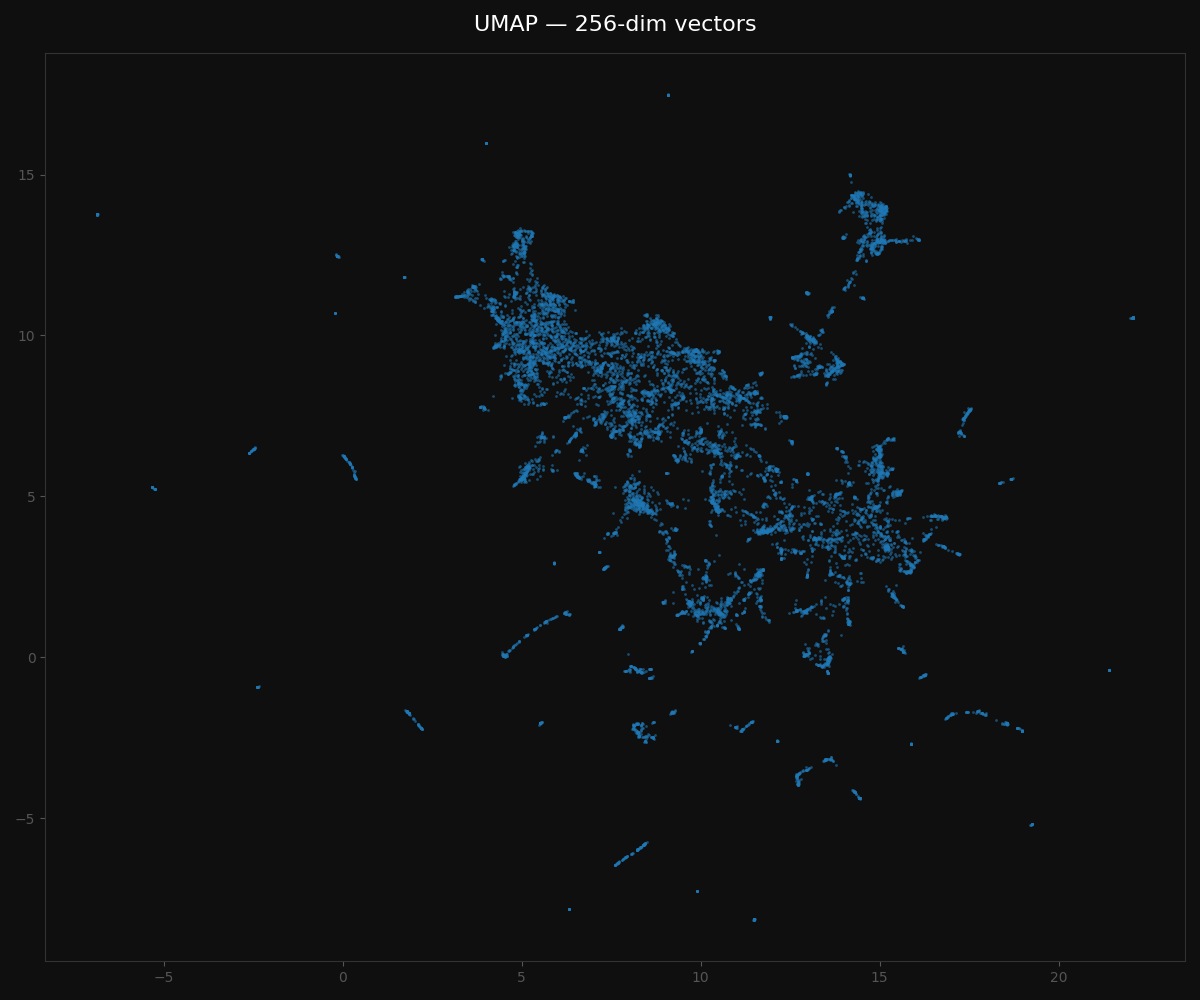

In [41]:
# ── Config ────────────────────────────────────────────────────────────────────
VECTORS_FILE = "db_files/vectors.bin"   # change path if needed
DIM = 256                       # vector dimensionality
DTYPE = np.float32
 
UMAP_N_NEIGHBORS = 15          # higher = more global structure
UMAP_MIN_DIST = 0.1            # lower = tighter clusters
UMAP_METRIC = "cosine"         # "cosine" or "euclidean"
 
OUTPUT_IMAGE = "umap_viz.png"
# ─────────────────────────────────────────────────────────────────────────────
 
def load_vectors(path):
    raw = np.fromfile(path, dtype=DTYPE)
    n = len(raw) // DIM
    vectors = raw[: n * DIM].reshape(n, DIM)
    print(f"Loaded {n} vectors of dim {DIM}")
    return vectors
 
def run_umap(vectors):
    print(f"Running UMAP on {len(vectors)} vectors...")
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        metric=UMAP_METRIC,
        random_state=42,
        verbose=True,
    )
    embedding = reducer.fit_transform(vectors)
    print("UMAP done.")
    return embedding
 
def plot(embedding):
    fig, ax = plt.subplots(figsize=(12, 10), facecolor="#0f0f0f")
    ax.set_facecolor("#0f0f0f")
 
    # color points by density using a 2D histogram
    n = len(embedding)
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        s=4,#max(1, min(8, 5000 / n)),   # scale point size to count
        #c=np.arange(n),
        cmap="plasma",
        alpha=0.6,
        linewidths=0,
    )
 
    ax.set_title("UMAP — 256-dim vectors", color="white", fontsize=16, pad=16)
    ax.tick_params(colors="#555")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")
 
    plt.tight_layout()
    plt.savefig(OUTPUT_IMAGE, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"Saved to {OUTPUT_IMAGE}")
    plt.show()
    
vectors = load_vectors(VECTORS_FILE)
embedding = run_umap(vectors)
plot(embedding)